## Práctica Repaso 1
Vamos a entrenar una red neuronal en PyTorch capaz de aproximar simultáneamente dos funciones matemáticas a partir de una única variable de entrada $x \in [-100, 100]$, donde las salidas están contaminadas con ruido gaussiano:

Señal 1: $y_1 = \sin(0.05 \cdot x) + \text{ruido}$

Señal 2: $y_2 = \frac{x^2}{1000} - 2 + \text{ruido}$

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader

class SensorData(Dataset):
    def __init__(self):
        super().__init__()

        # Genero los valores de x.
        x = torch.linspace(-100, 100, 3000)

        # Genero ruido para cada función.
        noise1 = torch.randn_like(x) * 0.1
        noise2 = torch.randn_like(x) * 0.1

        # Genero los valores de y a partir de x y del ruido gaussiano.
        y1 = torch.sin(0.05 * x) + noise1
        y2 = (torch.pow(x, 2) / 1000) - 2 + noise2

        # Normalizo los valores de x a [-1, 1] y le damos forma (1500, 1).
        self.x = (x/100).unsqueeze(1)

        # Empaquetamos ambas salidas.
        self.y = torch.stack([y1, y2], dim=1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [21]:
class NeuronalNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.entrance = torch.nn.Linear(1, 32) # OF. Usar aquí red=nn.Sequential() y en forward solo devuelvo la red.
        self.middle1 = torch.nn.Linear(32, 64)
        self.activation = torch.nn.LeakyReLU()
        self.middle2 = torch.nn.Linear(64, 32)
        self.output = torch.nn.Linear(32, 2)

    def forward(self, x):
        x = self.activation(self.entrance(x))
        x = self.activation(self.middle1(x))
        x = self.activation(self.middle2(x))
        # En regresión la última capa no lleva activación.
        x = self.output(x)
        return x


In [22]:
from torch.utils.data import random_split
dataset = SensorData()
train_dataset, val_dataset, test_dataset = random_split(dataset, [1800, 600, 600])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [26]:
model = NeuronalNetwork()
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda")
model.to(device)

epochs = 100

# Loss History
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    # --- FASE ENTRENAMIENTO ---
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Reiniciar gradientes
        optimizer.zero_grad()
        # Paso hacia delante (Predecir el modelo) - Forward
        y_pred = model(x_batch)
        # Calcular la pérdida
        loss = loss_fn(y_pred, y_batch)
        # Paso hacia detrás - Backward
        loss.backward()
        # Actualizar pesos
        optimizer.step()
        # Añado el error de este lote
        train_loss += loss.item()
    train_loss = loss.item() / len(train_loader)
    train_loss_history.append(train_loss)

    ## --- FASE EVALUACIÓN ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x_batch)
            loss = loss_fn(y_batch, y_pred)
            val_loss += loss.item()
        val_loss = val_loss / len(val_loader)
        val_loss_history.append(val_loss)

    print(f"Época [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Época [1/100] - Train Loss: 0.0749 | Val Loss: 1.4980
Época [2/100] - Train Loss: 0.0349 | Val Loss: 1.3640
Época [3/100] - Train Loss: 0.0273 | Val Loss: 0.9442
Época [4/100] - Train Loss: 0.0154 | Val Loss: 0.3914
Época [5/100] - Train Loss: 0.0113 | Val Loss: 0.1913
Época [6/100] - Train Loss: 0.0061 | Val Loss: 0.1435
Época [7/100] - Train Loss: 0.0047 | Val Loss: 0.1242
Época [8/100] - Train Loss: 0.0024 | Val Loss: 0.1207
Época [9/100] - Train Loss: 0.0033 | Val Loss: 0.1191
Época [10/100] - Train Loss: 0.0037 | Val Loss: 0.1090
Época [11/100] - Train Loss: 0.0024 | Val Loss: 0.1065
Época [12/100] - Train Loss: 0.0028 | Val Loss: 0.1070
Época [13/100] - Train Loss: 0.0059 | Val Loss: 0.1004
Época [14/100] - Train Loss: 0.0025 | Val Loss: 0.0969
Época [15/100] - Train Loss: 0.0025 | Val Loss: 0.0939
Época [16/100] - Train Loss: 0.0032 | Val Loss: 0.0937
Época [17/100] - Train Loss: 0.0022 | Val Loss: 0.0961
Época [18/100] - Train Loss: 0.0022 | Val Loss: 0.1113
Época [19/100] - Tr

In [27]:
# --- FASE TEST ---
model.eval()
test_loss = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)
        loss = loss_fn(y_batch, y_pred)
        test_loss += loss.item() # Escalar float ahorrando memoria VRAM
    test_loss = test_loss / len(test_loader)

    print(f"Test Loss: {test_loss:.4f}")


Test Loss: 0.0902


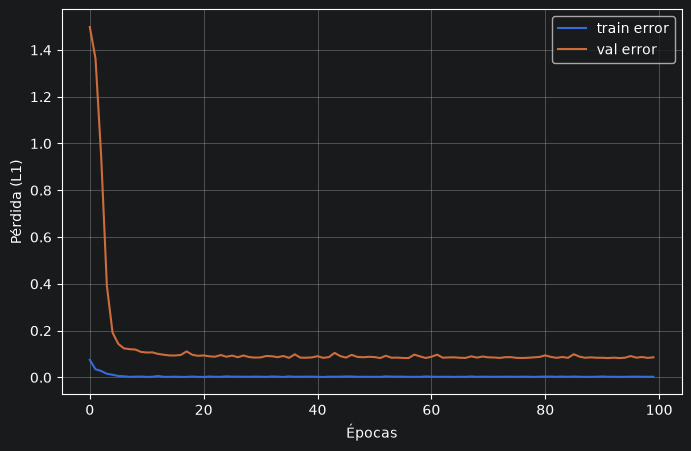

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="train error")
plt.plot(val_loss_history, label="val error")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (L1)")
plt.legend()
plt.grid(True)
plt.show()